# Margem máxima e SVM linear

**Tema:** Aprendizado Supervisionado › Máquinas de Vetores de Suporte

Este notebook visualiza a margem máxima literalmente — a "estrada mais
larga" entre duas classes —, identifica os vetores de suporte, e mede o
efeito do hiperparâmetro $C$ na largura da margem e no número de violações
toleradas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(21)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um caso linearmente separável, com margem visível

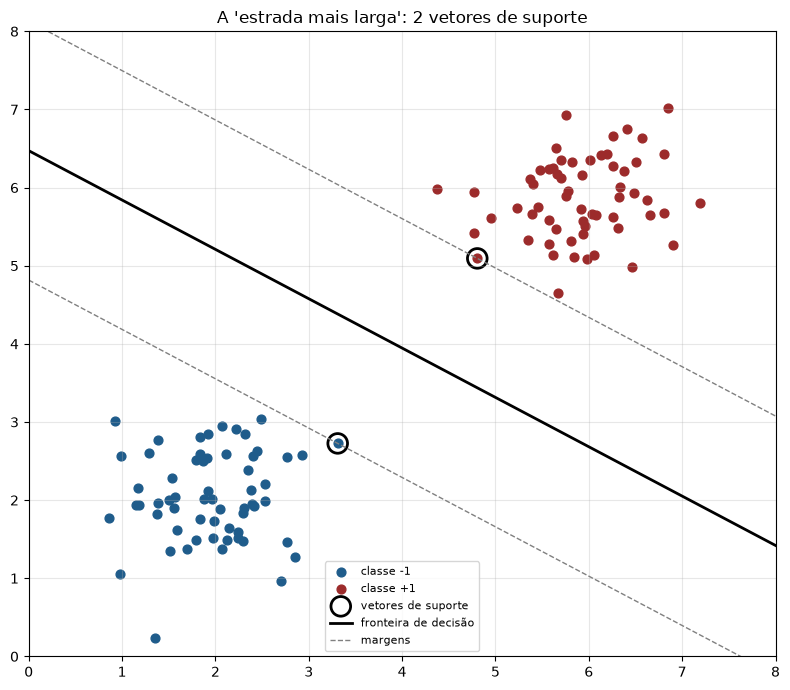

número de vetores de suporte: 2 de 120 pontos totais
Só esses pontos determinam a fronteira — remova qualquer outro ponto
e a fronteira encontrada não muda em nada.


In [2]:
n = 60
X_classe0 = rng.normal([2, 2], 0.6, (n, 2))
X_classe1 = rng.normal([6, 6], 0.6, (n, 2))
X = np.vstack([X_classe0, X_classe1])
y = np.concatenate([-np.ones(n), np.ones(n)])

modelo = SVC(kernel="linear", C=1000).fit(X, y)  # C grande ~ margem rígida

w = modelo.coef_[0]
b = modelo.intercept_[0]
vetores_suporte = modelo.support_vectors_

xx = np.linspace(0, 8, 100)
yy_fronteira = -(w[0] * xx + b) / w[1]
margem = 1 / np.linalg.norm(w)
yy_margem_superior = yy_fronteira + margem * np.sqrt(1 + (w[0] / w[1]) ** 2)
yy_margem_inferior = yy_fronteira - margem * np.sqrt(1 + (w[0] / w[1]) ** 2)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X[y == -1, 0], X[y == -1, 1], s=40, color=AZUL, label="classe -1")
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=40, color=VERMELHO, label="classe +1")
ax.scatter(vetores_suporte[:, 0], vetores_suporte[:, 1], s=200, facecolors="none",
          edgecolors="black", linewidths=2, label="vetores de suporte")
ax.plot(xx, yy_fronteira, color="black", lw=2, label="fronteira de decisão")
ax.plot(xx, yy_margem_superior, color="gray", lw=1, ls="--")
ax.plot(xx, yy_margem_inferior, color="gray", lw=1, ls="--", label="margens")
ax.set_xlim(0, 8); ax.set_ylim(0, 8)
ax.legend(fontsize=8); ax.set_title(f"A 'estrada mais larga': {len(vetores_suporte)} vetores de suporte")
plt.tight_layout(); plt.show()

print(f"número de vetores de suporte: {len(vetores_suporte)} de {len(X)} pontos totais")
print("Só esses pontos determinam a fronteira — remova qualquer outro ponto")
print("e a fronteira encontrada não muda em nada.")

## 2. Confirmando: remover pontos que NÃO são vetores de suporte não muda nada

In [3]:
indices_nao_suporte = [i for i in range(len(X))
                       if not np.any(np.all(np.isclose(X[i], vetores_suporte), axis=1))]
indices_removidos = rng.choice(indices_nao_suporte, size=min(20, len(indices_nao_suporte)),
                               replace=False)
mascara = np.ones(len(X), dtype=bool)
mascara[indices_removidos] = False

modelo_reduzido = SVC(kernel="linear", C=1000).fit(X[mascara], y[mascara])

print(f"coeficientes ORIGINAIS: {w}")
print(f"coeficientes SEM {len(indices_removidos)} pontos não-suporte: "
      f"{modelo_reduzido.coef_[0]}")
print(f"\ndiferença máxima: {np.abs(w - modelo_reduzido.coef_[0]).max():.2e}")

coeficientes ORIGINAIS: [0.38133175 0.60379018]
coeficientes SEM 20 pontos não-suporte: [0.38133175 0.60379018]

diferença máxima: 0.00e+00


## 3. O efeito de C: margem rígida vs. margem suave

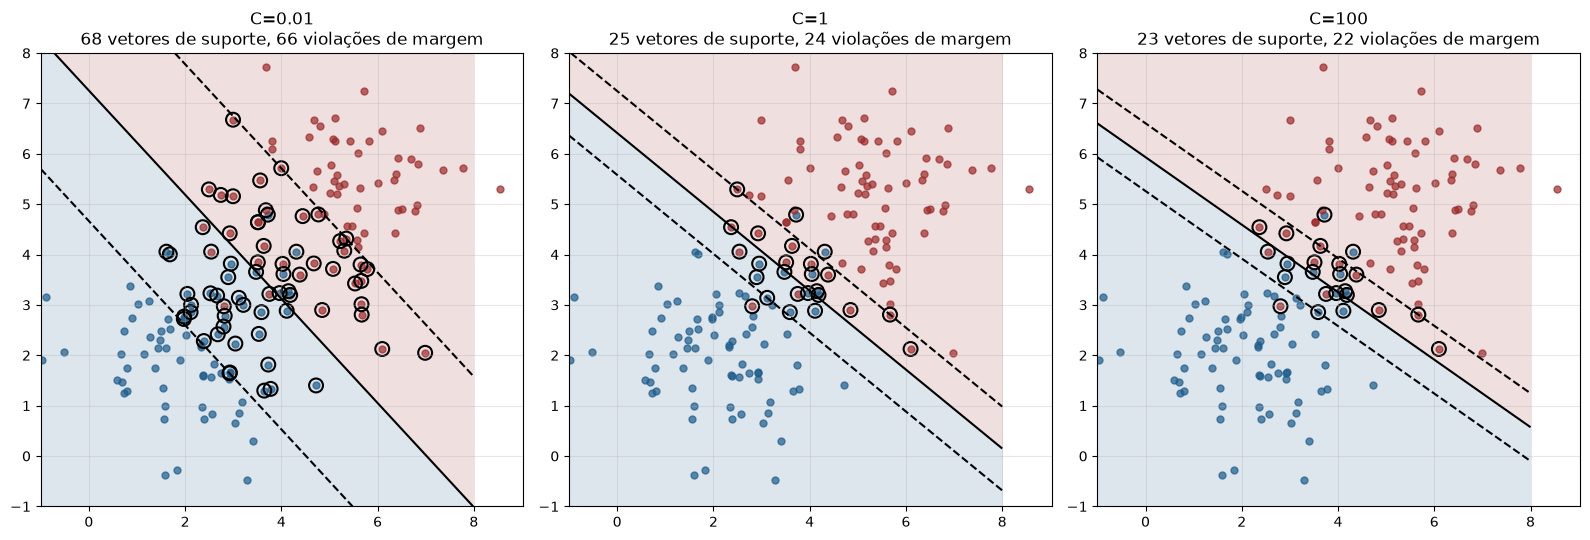

In [4]:
n = 80
X_classe0 = rng.normal([2, 2], 1.2, (n, 2))
X_classe1 = rng.normal([5, 5], 1.2, (n, 2))
X_sobreposto = np.vstack([X_classe0, X_classe1])
y_sobreposto = np.concatenate([-np.ones(n), np.ones(n)])

xx_grade, yy_grade = np.meshgrid(np.linspace(-1, 8, 200), np.linspace(-1, 8, 200))

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, C in zip(axes, [0.01, 1, 100]):
    modelo_c = SVC(kernel="linear", C=C).fit(X_sobreposto, y_sobreposto)
    Z = modelo_c.decision_function(np.column_stack([xx_grade.ravel(), yy_grade.ravel()]))
    Z = Z.reshape(xx_grade.shape)
    ax.contourf(xx_grade, yy_grade, Z, levels=[-1e9, 0, 1e9], colors=[AZUL, VERMELHO], alpha=0.15)
    ax.contour(xx_grade, yy_grade, Z, levels=[-1, 0, 1], colors="black",
              linestyles=["--", "-", "--"])
    ax.scatter(X_sobreposto[y_sobreposto == -1, 0], X_sobreposto[y_sobreposto == -1, 1],
              s=25, color=AZUL, alpha=0.7)
    ax.scatter(X_sobreposto[y_sobreposto == 1, 0], X_sobreposto[y_sobreposto == 1, 1],
              s=25, color=VERMELHO, alpha=0.7)
    ax.scatter(modelo_c.support_vectors_[:, 0], modelo_c.support_vectors_[:, 1],
              s=100, facecolors="none", edgecolors="black", linewidths=1.5)
    n_erros_margem = np.sum(y_sobreposto * modelo_c.decision_function(X_sobreposto) < 1)
    ax.set_title(f"C={C}\n{len(modelo_c.support_vectors_)} vetores de suporte, "
                f"{n_erros_margem} violações de margem")
plt.tight_layout(); plt.show()

**Leitura esperada:** com $C$ pequeno, a margem é larga e tolera muitas
violações (mais vetores de suporte, fronteira mais "conservadora"). Com
$C$ grande, a margem fica estreita e tenta classificar cada ponto
corretamente (menos vetores de suporte, fronteira mais ajustada aos dados
de treino — maior risco de overfitting).

## 4. Escolhendo C por validação cruzada

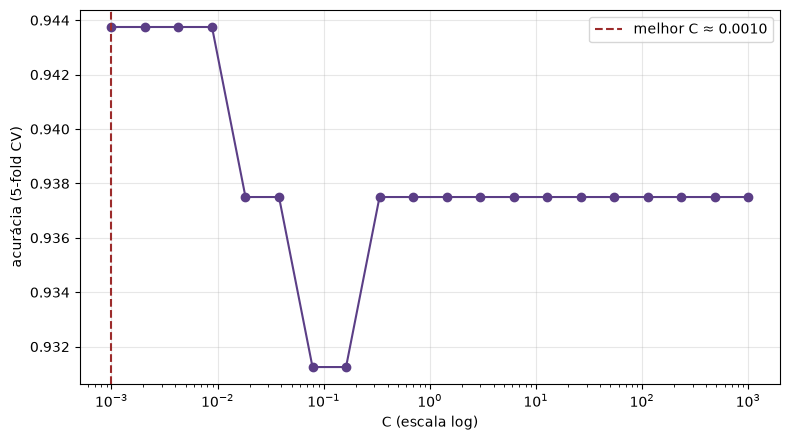

In [5]:
X_padronizado = StandardScaler().fit_transform(X_sobreposto)
valores_C = np.logspace(-3, 3, 20)
scores = [cross_val_score(SVC(kernel="linear", C=c), X_padronizado, y_sobreposto, cv=5).mean()
          for c in valores_C]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(valores_C, scores, "o-", color=ROXO)
ax.set_xscale("log")
ax.set_xlabel("C (escala log)"); ax.set_ylabel("acurácia (5-fold CV)")
ax.axvline(valores_C[np.argmax(scores)], color=VERMELHO, ls="--",
          label=f"melhor C ≈ {valores_C[np.argmax(scores)]:.4f}")
ax.legend(); plt.tight_layout(); plt.show()

## O que levar deste notebook

- A fronteira de uma SVM depende **só** dos vetores de suporte — remover
  qualquer outro ponto de treino não muda o resultado, confirmado
  numericamente.
- $C$ controla o trade-off entre margem larga (mais viés, mais tolerância
  a violações) e margem estreita (menos viés, mais variância).
- Como em k-NN e regressão logística, o hiperparâmetro certo vem de
  validação cruzada, não de um valor padrão ou palpite.

→ Próximo: **Kernels**, o truque que permite fronteiras não-lineares sem
nunca calcular explicitamente as features expandidas.